<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation1/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [106]:
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

3. Split the Dataset

Split the data into training and testing sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [6]:
# Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 77.44%
Confusion Matrix:
 [[56 16]
 [14 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        72
           1       0.75      0.77      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.78      0.77      0.77       133



In [7]:
# printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [1.47532634] [-1.67518769] [0.52654523]


# 2nd Logistic Regersion

This model is from the Applied Machine Learning with Python book-page 62

In [8]:
X = data.data
y = data.target
print(data.feature_names)
print(data.DESCR)


['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, bloo

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 80.45%
Confusion Matrix:
 [[56 16]
 [10 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81        72
           1       0.76      0.84      0.80        61

    accuracy                           0.80       133
   macro avg       0.80      0.81      0.80       133
weighted avg       0.81      0.80      0.80       133



### Comparing Coefficients of Scaled vs. Unscaled Models

In [12]:
print('Prediction:', lr.predict(X_test)[1], lr.predict(X_test)[9], lr.predict(X_test)[25])
print('Raw Model Output X_test: ',
      (lr.coef_@ X_test[1] + lr.intercept_),
      (lr.coef_@ X_test[9] + lr.intercept_),
      (lr.coef_@ X_test[25]+ lr.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [0.1352537] [-0.09852356] [0.17023003]


In [13]:
print("Scaled Model (model):")
print("  Coefficients:", model.coef_)
print("  Intercept:", model.intercept_)

print("\nUnscaled Model (lr):")
print("  Coefficients:", lr.coef_)
print("  Intercept:", lr.intercept_)

Scaled Model (model):
  Coefficients: [[ 0.10500243 -0.58724547  0.67459032  0.61835658 -0.32022822 -0.08939562
  -0.52441695  0.09787805  0.62173009 -0.04851767]]
  Intercept: [0.14722282]

Unscaled Model (lr):
  Coefficients: [[ 0.57359398 -0.65002523  2.35591272  1.85001384  0.18766705  0.06003926
  -1.59215119  1.32216707  1.94320318  1.15471231]]
  Intercept: [0.05378309]


# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [2]:
#import important libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import seaborn as sns
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [4]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data= pd.read_csv('/content/sample_data/diabetes.csv')
diab_data.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


### Building LR model

Descriptive statistics for 'glyhb' column:


,glyhb
count,390.000000
mean,5.589769
std,2.242595
min,2.680000
25%,4.380000
50%,4.840000
75%,5.600000
max,16.110001


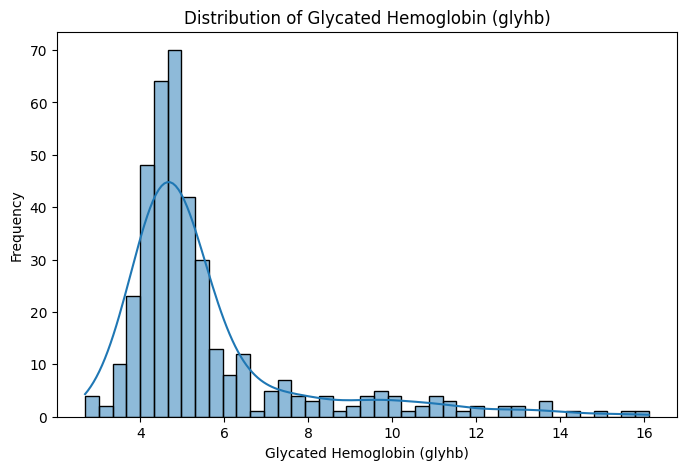

In [5]:
# 2.Understanding the 'glyhb' column
# Display descriptive statistics for 'glyhb'
print("Descriptive statistics for 'glyhb' column:")
display(diab_data['glyhb'].describe())

# Visualize the distribution of 'glyhb'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data['glyhb'].dropna(), kde=True)
plt.title('Distribution of Glycated Hemoglobin (glyhb)')
plt.xlabel('Glycated Hemoglobin (glyhb)')
plt.ylabel('Frequency')
plt.show()

In [6]:
diab_data

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.310000,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.440000,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.640000,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.630000,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.720000,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,41506,296.0,369,46.0,6.4,16.110001,Louisa,53,male,69.0,173.0,medium,138.0,94.0,130.0,94.0,35.0,39.0,210.0
399,41507,284.0,89,54.0,5.3,4.390000,Louisa,51,female,63.0,154.0,medium,140.0,100.0,146.0,102.0,32.0,43.0,180.0
400,41510,194.0,269,38.0,5.1,13.630000,Louisa,29,female,69.0,167.0,small,120.0,70.0,NaN,NaN,33.0,40.0,20.0
401,41752,199.0,76,52.0,3.8,4.490000,Louisa,41,female,63.0,197.0,medium,120.0,78.0,NaN,NaN,41.0,48.0,255.0


In [7]:
# 3 Exploring nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB
None


,0
id,0
chol,1
stab.glu,0
hdl,1
ratio,1
glyhb,13
location,0
age,0
gender,0
height,5


In [8]:
# 4 Cleaning data
# Droping all missing values
diab_data = diab_data.dropna(how='any')

In [9]:
# 5. Cheking nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 130 entries, 2 to 399
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        130 non-null    int64  
 1   chol      130 non-null    float64
 2   stab.glu  130 non-null    int64  
 3   hdl       130 non-null    float64
 4   ratio     130 non-null    float64
 5   glyhb     130 non-null    float64
 6   location  130 non-null    object 
 7   age       130 non-null    int64  
 8   gender    130 non-null    object 
 9   height    130 non-null    float64
 10  weight    130 non-null    float64
 11  frame     130 non-null    object 
 12  bp.1s     130 non-null    float64
 13  bp.1d     130 non-null    float64
 14  bp.2s     130 non-null    float64
 15  bp.2d     130 non-null    float64
 16  waist     130 non-null    float64
 17  hip       130 non-null    float64
 18  time.ppn  130 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 20.3+ KB
None


,0
id,0
chol,0
stab.glu,0
hdl,0
ratio,0
glyhb,0
location,0
age,0
gender,0
height,0


In [10]:
# 6. Converting string data to number (Location, Gender, and Fram) for finding the correlattion between them
gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)

location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)

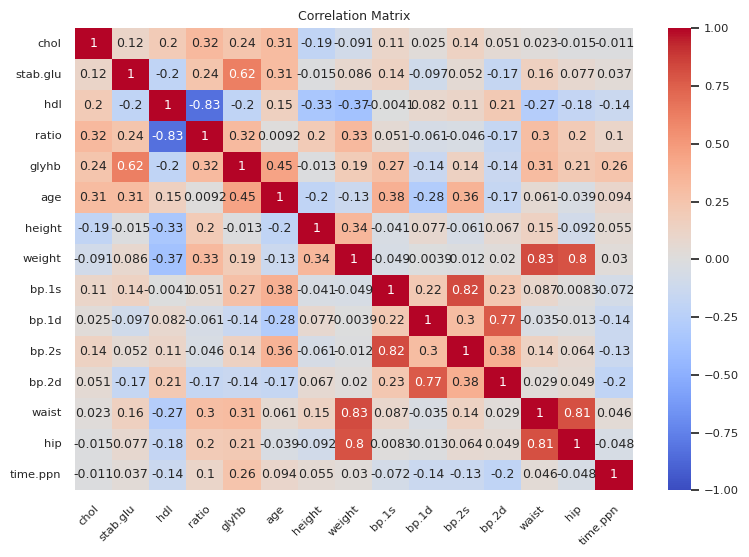

In [11]:
# 7. Cleaning dataset from the unnacessory columns ('id','location', 'gender','frame') to show clear corelationship
corr = diab_data.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()


In [12]:
# 8. Deleting unusfel columns that show low correlation with glyb label
diab_data_corr = diab_data.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
for col in diab_data_corr.columns:
   if (diab_data_corr['glyhb'].corr(diab_data_corr[col])<=0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)

In [13]:
diab_data_corr.head()

,chol,stab.glu,ratio,glyhb,age,weight,bp.1s,waist,hip,time.ppn
chol,1.000000,0.116375,0.323465,0.242585,0.306924,-0.090847,0.106586,0.023064,-0.015494,-0.011211
stab.glu,0.116375,1.000000,0.242374,0.620495,0.310757,0.085603,0.137116,0.155825,0.077374,0.037183
hdl,0.197826,-0.202307,-0.828486,-0.197688,0.149150,-0.369140,-0.004119,-0.271310,-0.176124,-0.139666
ratio,0.323465,0.242374,1.000000,0.316706,0.009171,0.327716,0.051445,0.295999,0.197214,0.101641
glyhb,0.242585,0.620495,0.316706,1.000000,0.448514,0.190163,0.274265,0.309677,0.214842,0.256765


In [115]:
# This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data_corr = diab_data_corr.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data_corr['glyhb'].corr(diab_data_corr[col])

   if (correlation <= 0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")


False: Column 'chol' kept (Correlation: 0.44)
False: Column 'stab.glu' kept (Correlation: 0.82)
False: Column 'ratio' kept (Correlation: 0.46)
Skipping target column: 'glyhb'
True: Column 'location' dropped due to correlation <= 0 (Correlation: 0.00)
False: Column 'age' kept (Correlation: 0.37)
True: Column 'gender' dropped due to correlation <= 0 (Correlation: 0.00)
False: Column 'height' kept (Correlation: 0.10)
False: Column 'weight' kept (Correlation: 0.12)
True: Column 'frame' dropped due to correlation <= 0 (Correlation: 0.00)
False: Column 'bp.1s' kept (Correlation: 0.10)
False: Column 'bp.2s' kept (Correlation: 0.02)
False: Column 'waist' kept (Correlation: 0.18)
False: Column 'hip' kept (Correlation: 0.07)
False: Column 'time.ppn' kept (Correlation: 0.18)
Total columns dropped: 3


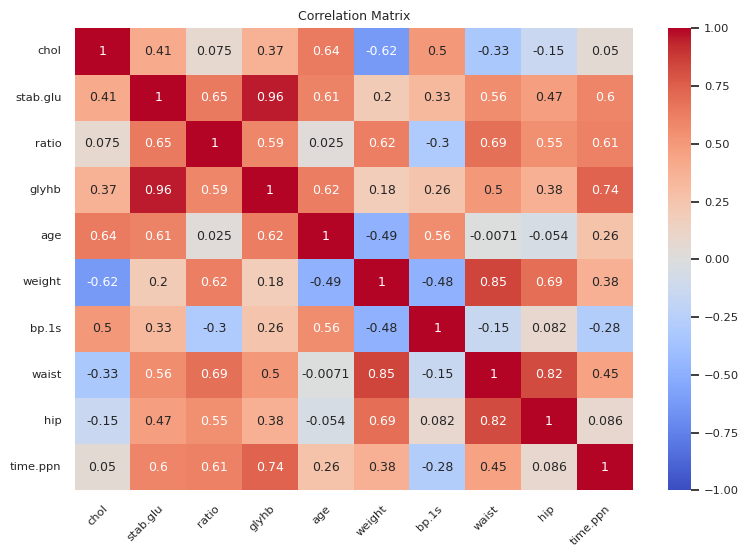

In [16]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [117]:
diat_data_corr = diab_data_corr.drop('height', axis=1)
diat_data_corr.head()

,chol,stab.glu,ratio,glyhb,age,weight,bp.1s,bp.2s,waist,hip,time.ppn
2,228.0,92,6.2,4.64,58,256.0,190.0,185.0,49.0,57.0,180.0
6,195.0,92,4.8,4.84,30,191.0,161.0,161.0,46.0,49.0,720.0
8,177.0,87,3.6,4.84,45,166.0,160.0,128.0,34.0,40.0,300.0
10,242.0,82,4.5,4.77,60,156.0,130.0,130.0,39.0,45.0,300.0
15,213.0,83,4.5,3.41,33,157.0,130.0,120.0,37.0,41.0,240.0


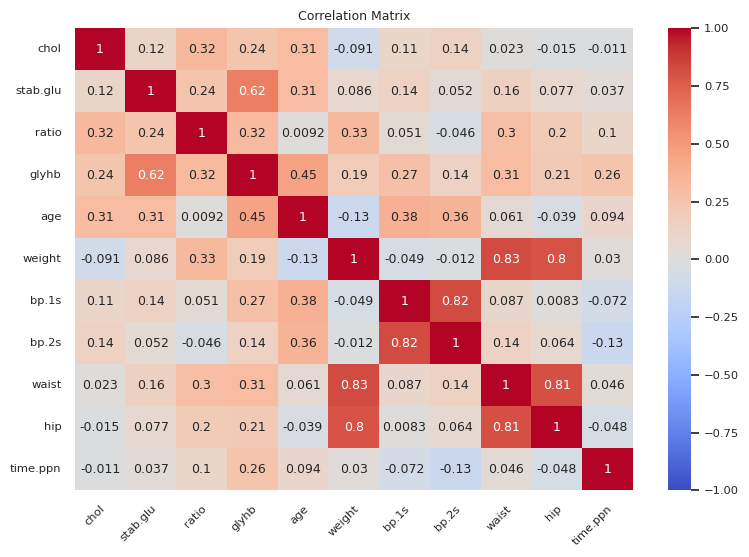

In [139]:
# printing heatmap to check there is no correlatioun less than 0
corr1 = diat_data_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr1, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [151]:
# Building data for the model
X = diat_data_corr.drop('glyhb', axis=1)
y = diat_data_corr['glyhb']

# Cleaning data
X = X.dropna(how='any')
y = y.dropna(how='any')

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
y_binary = (y >= 6.5).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [152]:
# Building the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [153]:
# Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 84.62%
Confusion Matrix:
 [[29  1]
 [ 5  4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91        30
           1       0.80      0.44      0.57         9

    accuracy                           0.85        39
   macro avg       0.83      0.71      0.74        39
weighted avg       0.84      0.85      0.83        39



In [154]:
# printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))

Prediction: 0 1 0
Raw Model Output X_test:  [-3.38553748] [3.06983673] [-3.03029578]


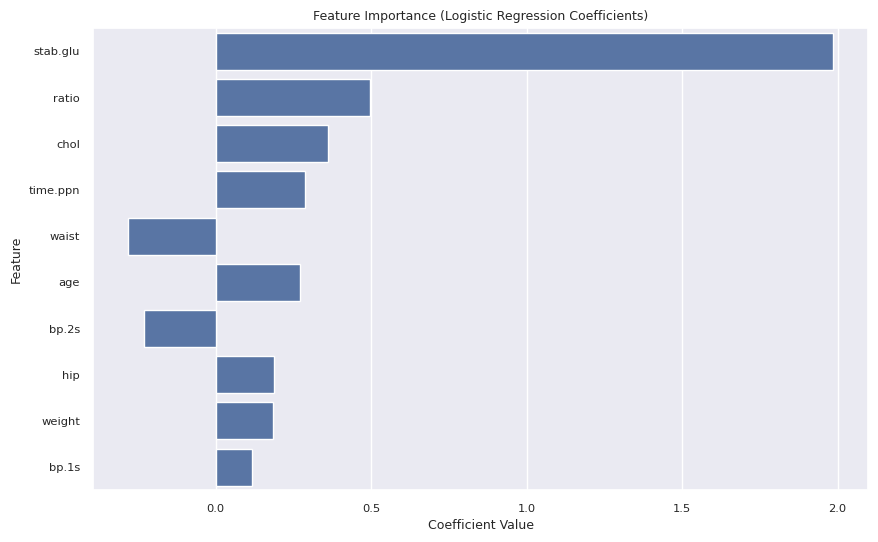

In [155]:
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()





-------------------------
# This part is for demo test

---



In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

In [ ]:
diabetes.data[:3]

# Linear Regression

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()